# 05 — Backward Factor Trace Through a Tiny Vision Transformer

This notebook applies the **Backward Factor Trace (BFT)** algorithm to a transformer,
tracing through **both the attention sublayer and the FFN sublayer** of a single transformer block.

**Architecture:** A minimal 1-block ViT (embed_dim=32, 2 heads, ffn_dim=64) trained on MNIST even/odd.

**Layers traced** (forward order, BFT runs backward):
```
B0-V   (attn)  W_V: (32, 32)   input: (N, 17, 32) all tokens
B0-O   (fc)    W_O: (32, 32)   input: (N, 32)      attention output
B0-FFN1 (fc)   W:   (64, 32)   input: (N, 32)      CLS after residual+LN
B0-FFN2 (fc)   W:   (32, 64)   input: (N, 64)      after GELU
```

Section 6 explains exactly how BFT handles the attention layer, which does not have
a fixed weight matrix the way an FC layer does.

## 1. Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib

from src import bft
from src.data_utils import get_mnist_loaders
from src.training import label_transform_even_odd

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)
FIG_DIR   = os.path.join(_repo_dir, 'figs', '05_transformer_trace')
os.makedirs(FIG_DIR, exist_ok=True)

matplotlib.rcParams.update({'figure.dpi': 80})
print(f'FIG_DIR: {FIG_DIR}')

device: cpu
FIG_DIR: /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace


## 2. Dataset

In [2]:
train_loader, test_loader = get_mnist_loaders(batch_size=256, root='../data/')
CLASS_NAMES = {0: 'even', 1: 'odd'}
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 235 | Test batches: 40


## 3. Simplified Architecture

One transformer block with deliberately small dimensions to keep the trace interpretable:

```
28×28 image → 16 patches of 7×7 → Linear(49, 32) → embed_dim=32
Prepend CLS token → sequence length T=17
Add positional embedding

TransformerBlock (×1):
  LN1 → MultiHeadAttention(dim=32, heads=2, d_head=16) → residual
  LN2 → FFN: Linear(32→64) → GELU → Linear(64→32) → residual

LN → CLS[0] → Linear(32, 2) → log_softmax
```

~18k parameters total. The block stores all intermediate activations when `capture=True`.

In [3]:
from src import PatchEmbedder, TransformerBlock, TinyViT

EMBED_DIM = 32
model = TinyViT(embed_dim=EMBED_DIM).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 10,850


## 4. Training

Epoch  1 | loss 0.2994 | test acc 0.9257
Epoch  2 | loss 0.1687 | test acc 0.9456
Epoch  3 | loss 0.1402 | test acc 0.9603
Epoch  4 | loss 0.1175 | test acc 0.9524
Epoch  5 | loss 0.1073 | test acc 0.9616
Epoch  6 | loss 0.0999 | test acc 0.9605
Epoch  7 | loss 0.0943 | test acc 0.9651
Epoch  8 | loss 0.0899 | test acc 0.9703
Epoch  9 | loss 0.0863 | test acc 0.9690
Epoch 10 | loss 0.0841 | test acc 0.9714
Epoch 11 | loss 0.0793 | test acc 0.9714
Epoch 12 | loss 0.0764 | test acc 0.9740
Epoch 13 | loss 0.0763 | test acc 0.9719
Epoch 14 | loss 0.0735 | test acc 0.9733
Epoch 15 | loss 0.0730 | test acc 0.9760


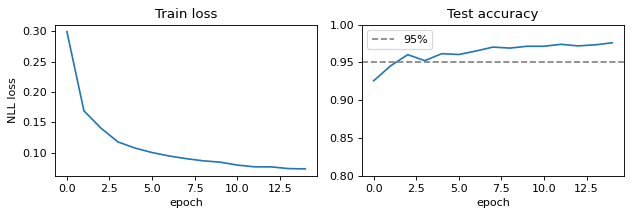

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.NLLLoss()
N_EPOCHS  = 15
train_losses, test_accs = [], []

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0.0
    for imgs, digits in train_loader:
        imgs   = imgs.to(device)
        labels = label_transform_even_odd(digits).to(device)
        loss   = criterion(model(imgs), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    n_correct = 0
    with torch.no_grad():
        for imgs, digits in test_loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digits).to(device)
            n_correct += (model(imgs).argmax(1) == labels).sum().item()
    acc = n_correct / len(test_loader.dataset)
    train_losses.append(total_loss / len(train_loader))
    test_accs.append(acc)
    print(f'Epoch {epoch+1:2d} | loss {train_losses[-1]:.4f} | test acc {acc:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.8))
ax1.plot(train_losses)
ax1.set(title='Train loss', xlabel='epoch', ylabel='NLL loss')
ax2.plot(test_accs)
ax2.axhline(0.95, ls='--', color='gray', label='95%')
ax2.set(title='Test accuracy', xlabel='epoch', ylim=(0.8, 1.0))
ax2.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()

In [5]:
import os as _os, json as _json
import torch as _torch

_exp_dir = _os.path.join('..', 'experiments', 'mnist_even_odd_vit_tiny')
_os.makedirs(_exp_dir, exist_ok=True)
_torch.save(model.state_dict(), _os.path.join(_exp_dir, 'weights.pt'))
with open(_os.path.join(_exp_dir, 'config.json'), 'w') as _f:
    _json.dump({
        'arch': 'TinyViT', 'embed_dim': EMBED_DIM,
        'n_heads': 2, 'ffn_dim': 64, 'n_classes': 2,
        'dataset': 'MNIST', 'label_transform': 'even_odd',
    }, _f, indent=2)
print(f'Saved: {_os.path.abspath(_exp_dir)}')

Saved: /Users/johannesbertram/repos/Weight_Interpretability/experiments/mnist_even_odd_vit_tiny


## 5. Activation Collection

Run the test set through the model with `capture=True`. For each correctly-classified sample we store:

| Key | Shape | Meaning |
|---|---|---|
| `attn_in` | `(N, 17, 32)` | All 17 token vectors entering MHA (post-LN1) |
| `attn_w`  | `(N, 17)` | Head-averaged CLS→token attention scores |
| `attn_out_cls` | `(N, 32)` | MHA output for CLS token (before W_O, before residual) |
| `ffn1_in` | `(N, 32)` | CLS token entering FFN (post-LN2, post-residual) |
| `ffn2_in` | `(N, 64)` | CLS token after FFN1 + GELU |

In [6]:
model.eval()
acts = {'attn_in': [], 'attn_w': [], 'attn_out_cls': [], 'ffn1_in': [], 'ffn2_in': []}
all_images, all_targets, all_digits = [], [], []

with torch.no_grad():
    for imgs, digits in test_loader:
        imgs   = imgs.to(device)
        labels = label_transform_even_odd(digits)
        logits = model(imgs, capture=True)
        mask   = (logits.argmax(1).cpu() == labels)
        if not mask.any():
            continue

        blk = model.block
        acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())          # (B, 17, 32)
        # head-averaged CLS row: (B, heads, T, T) -> mean heads -> CLS row -> (B, T)
        acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())
        acts['attn_out_cls'].append(blk._attn_out[mask, 0].cpu().numpy()) # (B, 32)
        acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())       # (B, 32)
        acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())       # (B, 64)

        all_images.append(imgs[mask].cpu().numpy())
        all_targets.append(labels[mask].numpy())
        all_digits.append(digits[mask].numpy())

for k in acts:
    acts[k] = np.concatenate(acts[k], axis=0)
all_images  = np.concatenate(all_images,  axis=0)
all_targets = np.concatenate(all_targets, axis=0)
all_digits  = np.concatenate(all_digits,  axis=0)

print(f'Correctly classified: {len(all_targets)}')
for k, v in acts.items():
    print(f'  {k}: {v.shape}')

Correctly classified: 9760
  attn_in: (9760, 17, 32)
  attn_w: (9760, 17)
  attn_out_cls: (9760, 32)
  ffn1_in: (9760, 32)
  ffn2_in: (9760, 64)


## 6. How BFT Traces Through Attention

### BFT recap for an FC layer

For a fully-connected layer with weight matrix $W \in \mathbb{R}^{n_{out} \times n_{in}}$ and
input activations $X \in \mathbb{R}^{N \times n_{in}}$, BFT forms a **joint arbor matrix**:

$$
J[n, :] = \bigl[\, W[0] \odot \hat{x}_n \;\|\; W[1] \odot \hat{x}_n \;\|\; \cdots \;\|\; W[n_{out}-1] \odot \hat{x}_n \,\bigr]
\in \mathbb{R}^{n_{out} \cdot n_{in}}
$$

where $\hat{x}_n = x_n / \|x_n\|$ is the L2-normalised input.
Each block $W[i] \odot \hat{x}_n$ is the **synaptic arbor** of output neuron $i$ on stimulus $n$:
the element-wise product of the neuron's weights with the normalised input.

NMF on $J$ (clipped to non-negative) gives factors shared across neurons.

---

### The problem with attention

In an attention sublayer, the "weight matrix" that transforms tokens into values is $W_V$,
but the actual computation mixes *all* tokens:

$$
\text{out}_n^{\text{CLS}} = \sum_{j=0}^{T-1} \alpha_{n,j} \;\bigl(x_{n,j} W_V^\top\bigr)
$$

where $\alpha_{n,j}$ are the **attention scores** (softmax output, non-negative, sum to 1) from
the CLS token to token $j$, and $x_{n,j} \in \mathbb{R}^{d}$ is token $j$'s representation.

This is **not** a fixed linear map: the mixing weights $\alpha$ depend on the input.
We cannot directly substitute $W = W_V$ and $x = x_{n,j}$ into the FC formula.

---

### The BFT solution: attention-weighted effective input

We collapse the token sequence into a **single effective input** per sample by computing
the attention-weighted average of the token vectors:

$$
x^{\text{eff}}_n = \sum_{j=0}^{T-1} \alpha_{n,j} \; x_{n,j} \;\in\; \mathbb{R}^{d}
$$

Because the scores $\alpha_{n,j}$ are non-negative and sum to 1, $x^{\text{eff}}_n$ is a
convex combination of the token vectors — a weighted average of the information the model
selects from the token sequence.

We then form the joint arbor exactly as for an FC layer:

$$
J^{\text{attn}}[n, :] = \bigl[\, W_V[0] \odot \hat{x}^{\text{eff}}_n \;\|\; \cdots \;\|\; W_V[d_v-1] \odot \hat{x}^{\text{eff}}_n \,\bigr]
$$

This is implemented in `src/bft.compute_attn_joint_arbors`.

**What this captures:** which token content (as selected by the attention pattern) co-activates
which output dimensions of $W_V$, across stimuli.

**What is approximated:** the per-token spatial resolution is lost — we work with one blended
vector per sample. The stored `attn_weights` in the BFT node can be used afterward
to project factors back to patch space for spatial grounding (Section 8).

---

### The full 4-layer chain

BFT runs backward from the last layer. For our 1-block ViT:

```
Forward:  [B0-V (attn)] → [B0-O (fc)] → [B0-FFN1 (fc)] → [B0-FFN2 (fc)]
BFT runs: B0-FFN2 → B0-FFN1 → B0-O → B0-V
```

At each backward step, the NMF loadings from the current layer become **stimulus weights**
for the next (earlier) layer, concentrating the trace on samples that activate the current factor.

## 7. Extract Weights & Build Layer Dicts

In [7]:
# nn.MultiheadAttention concatenates Q, K, V projections in in_proj_weight:
#   W_Q = in_proj_weight[:d, :]    shape (d, d)
#   W_K = in_proj_weight[d:2d, :]  shape (d, d)
#   W_V = in_proj_weight[2d:, :]   shape (d, d)   <- this is what we trace
D = EMBED_DIM
W_V = model.block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()  # (32, 32)
W_O = model.block.attn.out_proj.weight.detach().cpu().numpy()           # (32, 32)
W_f1 = model.block.ffn1.weight.detach().cpu().numpy()                   # (64, 32)
W_f2 = model.block.ffn2.weight.detach().cpu().numpy()                   # (32, 64)

# For B0-O we need the attention output for the CLS token before W_O is applied.
# nn.MultiheadAttention computes:  concat_heads @ W_O^T
# The input to W_O is the concatenated head outputs — captured as _attn_out (CLS token).
attn_out_cls = acts['attn_out_cls']   # (N, 32) — already extracted above

layer_dicts = [
    # Attention sublayer: W_V traces the value projection
    # input_fmap = all token activations, attn_weights = CLS attention scores
    {'type': 'attn', 'name': 'B0-V',
     'weight':       W_V,
     'input_fmap':   acts['attn_in'],      # (N, 17, 32)
     'attn_weights': acts['attn_w']},      # (N, 17)

    # Output projection: standard FC, input = attn_out for CLS token
    {'type': 'fc', 'name': 'B0-O',
     'weight':    W_O,
     'input_fmap': attn_out_cls},          # (N, 32)

    # FFN sublayer
    {'type': 'fc', 'name': 'B0-FFN1',
     'weight':    W_f1,
     'input_fmap': acts['ffn1_in']},       # (N, 32)

    {'type': 'fc', 'name': 'B0-FFN2',
     'weight':    W_f2,
     'input_fmap': acts['ffn2_in']},       # (N, 64)
]

print('Layer chain (forward order):')
for d in layer_dicts:
    print(f"  {d['name']:<10} type={d['type']:<5}  W:{str(d['weight'].shape):<12}  "
          f"input:{d['input_fmap'].shape}")

Layer chain (forward order):
  B0-V       type=attn   W:(32, 32)      input:(9760, 17, 32)
  B0-O       type=fc     W:(32, 32)      input:(9760, 32)
  B0-FFN1    type=fc     W:(64, 32)      input:(9760, 32)
  B0-FFN2    type=fc     W:(32, 64)      input:(9760, 64)


## 8. Run BFT

In [8]:
tree_root = bft(
    layer_dicts,
    n_branches=[1, 2, 2, 2],   # single trace — one pathway from output to input
    k_max=[10, 10, 5, 3],
    verbose=1,
)

# Walk the primary path: root is the last (output-side) layer
def spine(root):
    chain, node = [root], root
    while node['children']:
        node = node['children'][0]
        chain.append(node)
    return chain

# trace[0] = B0-FFN2 (output side), trace[-1] = B0-V (input side)
trace = spine(tree_root)

print(f"\n{'Layer':<12}  type   k*   lambda[:4]")
for r in trace:
    lstr = np.round(r['lambdas'][:4], 3).tolist()
    print(f"  {r['layer_name']:<12} {r['layer_type']:<5}  {len(r['lambdas'])}    {lstr}")

[BFT] Layer 4/4 'B0-FFN2' (fc)  path=[]  factorizer=sklearn
[BFT L4 'B0-FFN2' (fc)]   K=3  t=0.833s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[0]  factorizer=sklearn
[BFT L3 'B0-FFN1' (fc)]   K=5  t=2.366s
[BFT] Layer 2/4 'B0-O' (fc)  path=[0, 0]  factorizer=sklearn
[BFT L2 'B0-O' (fc)]   K=10  t=4.661s
[BFT] Layer 1/4 'B0-V' (attn)  path=[0, 0, 0]  factorizer=sklearn


KeyboardInterrupt: 

## 9. Results

### 9a. Lambda Spectra

Effective rank (number of NMF components selected) and importance distribution at each layer.

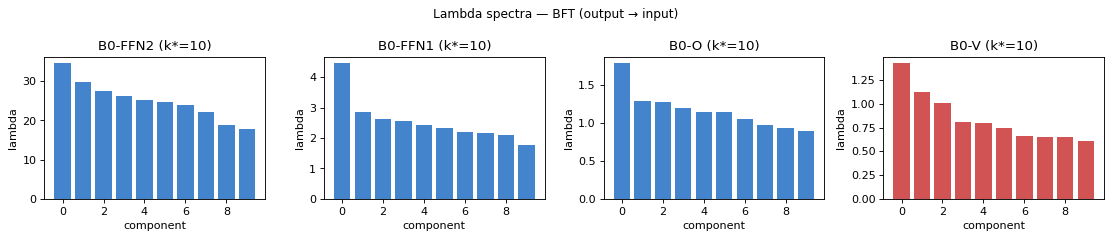

In [ ]:
fig, axes = plt.subplots(1, len(trace), figsize=(3.5 * len(trace), 3.0))
if len(trace) == 1:
    axes = [axes]

for ax, r in zip(axes, trace):
    lams = r['lambdas']
    color = '#C62828' if r['layer_type'] == 'attn' else '#1565C0'
    ax.bar(range(len(lams)), lams, color=color, alpha=0.8)
    ax.set(title=f"{r['layer_name']} (k*={len(lams)})",
           xlabel='component', ylabel='lambda')

fig.suptitle('Lambda spectra — BFT (output → input)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'lambda_spectra.png'), dpi=120, bbox_inches='tight')
plt.show()

### 9b. Factor-Loading Class Separation

For each layer, plot the distribution of the top factor's loading for even vs. odd samples.
Good separation means the factor tracks class-relevant structure.

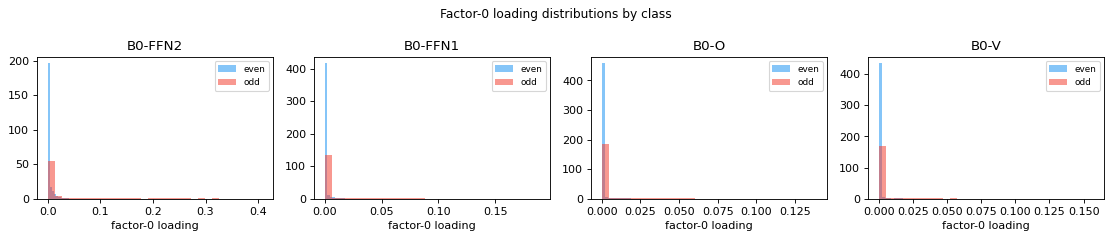

In [ ]:
fig, axes = plt.subplots(1, len(trace), figsize=(3.5 * len(trace), 3.0))
if len(trace) == 1:
    axes = [axes]

for ax, r in zip(axes, trace):
    coefs = r['img_factors'][:, 0]
    for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], ['even', 'odd']):
        ax.hist(coefs[all_targets == cl], bins=30, alpha=0.55, density=True,
                color=color, label=name)
    ax.set(title=r['layer_name'], xlabel='factor-0 loading')
    ax.legend(fontsize=8)

fig.suptitle('Factor-0 loading distributions by class', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'factor_loading_dist.png'), dpi=120, bbox_inches='tight')
plt.show()

### 9c. Factor-Weighted Average Images

Weight each test image by its factor-0 loading and compute the weighted average.
This shows which visual patterns drive the top NMF factor at each layer.

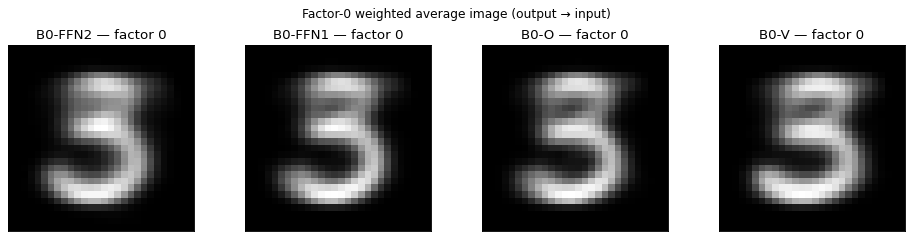

In [ ]:
fig, axes = plt.subplots(1, len(trace), figsize=(3.0 * len(trace), 3.0))
if len(trace) == 1:
    axes = [axes]

for ax, r in zip(axes, trace):
    coefs = r['img_factors'][:, 0]
    w     = coefs / (coefs.sum() + 1e-12)
    w_avg = (w[:, None, None] * all_images[:, 0]).sum(0)
    ax.imshow(w_avg, cmap='gray')
    ax.set(title=f"{r['layer_name']} — factor 0", xticks=[], yticks=[])

fig.suptitle('Factor-0 weighted average image (output → input)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'weighted_avg_images.png'), dpi=120, bbox_inches='tight')
plt.show()

### 9d. Attention Spatial Grounding

For the B0-V (attention) layer, we can project the factor loadings back into patch space.
Each sample has attention scores $\alpha_{n,j}$ over 16 patches (+ CLS). The factor-weighted
average attention map shows *which patches* the high-loading samples attend to:

$$
\text{avg\_attn\_grid}[p] = \sum_n w_n \cdot \alpha_{n, p+1}
$$

where $w_n$ is the factor-0 loading of sample $n$ (normalised to sum to 1) and $p+1$
indexes patch tokens (skipping the CLS token at position 0).

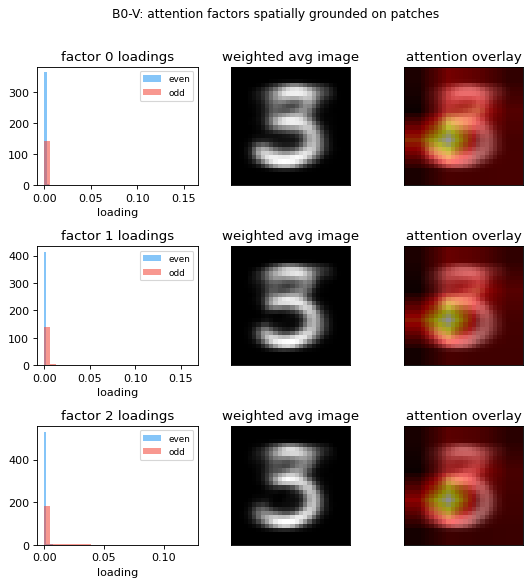

In [ ]:
# Find the B0-V node in the trace
attn_node = next((r for r in trace if r['layer_name'] == 'B0-V'), None)

if attn_node is None:
    print('B0-V node not found in trace')
else:
    n_factors = min(3, attn_node['img_factors'].shape[1])
    fig, axes = plt.subplots(n_factors, 3, figsize=(7, 2.4 * n_factors), squeeze=False)

    attn_patch_scores = attn_node['attn_weights'][:, 1:]  # (N, 16) drop CLS self-attention

    for fi in range(n_factors):
        coefs = attn_node['img_factors'][:, fi]
        w     = coefs / (coefs.sum() + 1e-12)             # normalised loading weights

        # Weighted average input image
        w_avg = (w[:, None, None] * all_images[:, 0]).sum(0)

        # Factor-weighted average attention map over patches
        avg_attn  = (w[:, None] * attn_patch_scores).sum(0)   # (16,)
        attn_grid = avg_attn.reshape(4, 4)                     # 4×4 patch grid
        attn_up   = F.interpolate(
            torch.tensor(attn_grid).float().unsqueeze(0).unsqueeze(0),
            size=(28, 28), mode='bilinear', align_corners=False,
        ).squeeze().numpy()

        # Class histogram
        ax = axes[fi, 0]
        for cl, color, lbl in zip([0, 1], ['#2196F3', '#F44336'], ['even', 'odd']):
            ax.hist(coefs[all_targets == cl], bins=25, alpha=0.55,
                    density=True, color=color, label=lbl)
        ax.set(title=f'factor {fi} loadings', xlabel='loading')
        ax.legend(fontsize=8)

        # Weighted average image
        axes[fi, 1].imshow(w_avg, cmap='gray')
        axes[fi, 1].set(title='weighted avg image', xticks=[], yticks=[])

        # Attention overlay
        axes[fi, 2].imshow(w_avg, cmap='gray')
        axes[fi, 2].imshow(attn_up, cmap='hot', alpha=0.55, vmin=0)
        axes[fi, 2].set(title='attention overlay', xticks=[], yticks=[])

    fig.suptitle('B0-V: attention factors spatially grounded on patches', fontsize=11, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'attn_spatial_grounding.png'), dpi=120, bbox_inches='tight')
    plt.show()

## 10. Discussion

### What the trace reveals

BFT runs from `B0-FFN2` (closest to the classifier) back to `B0-V` (the value projection).
At each step the NMF factor loadings propagate as stimulus weights to the earlier layer,
so the attention layer's arbors are computed only for samples that were already flagged as
relevant by the FFN layers.

### Approximation in the attention layer

The effective-input approximation $x^{\text{eff}}_n = \sum_j \alpha_{n,j} x_{n,j}$ is
exact when only one token is attended to ($\alpha$ is one-hot) and a weighted average
otherwise. For MNIST, where the CLS token typically attends to a handful of discriminative
patches, the approximation is tight. For tasks with more distributed attention (e.g.,
long-range dependencies) per-token attribution would require a separate factorisation
per token.

### Residual stream

The current trace treats each sublayer independently. Transformer blocks add to a
shared residual stream, so the FFN input already contains attention-mixed information
plus the original token representation. A full circuit trace would decompose along
the residual dimension (as in mechanistic interpretability work on GPT-2), which is
a natural extension of BFT.

## 10. Per-Factor Trace — Multiple Last-Layer Factors

Re-run BFT with `n_branches=[1,1,1,3]`: follow the **top 3 factors** of `B0-FFN2` (the output-side layer) independently backward through the chain. This produces 3 separate traces, each seeded by a different computational pathway discovered at the last layer.

For each path the plots below mirror NB02 Section 4:

- **Row 0** — lambda bar, stimulus-weight histogram by class, ranked factor-0 loading scatter
- **Rows 1–k\*** — per factor: weighted-average image · neural factor heatmap (`n_out×n_in`) · top-4 highest-loading samples
- **Attention layers** additionally show an attention-map overlay next to the weighted-average image

In [ ]:
import matplotlib.gridspec as gridspec

# Re-run BFT with 3 branches at the last layer (B0-FFN2).
# n_branches is indexed in forward order: [B0-V, B0-O, B0-FFN1, B0-FFN2]
N_LAST_FACTORS = 3
N_VIZ          = 3   # factor rows to show per layer

tree_multi = bft(
    layer_dicts,
    n_branches=[1, 1, 1, N_LAST_FACTORS],
    k_max=10,
    verbose=1,
)

def get_all_paths(root):
    """All root-to-leaf paths, each a list of nodes from last layer to first."""
    if not root['children']:
        return [[root]]
    return [[root] + p for child in root['children'] for p in get_all_paths(child)]

all_paths = get_all_paths(tree_multi)
print(f'{len(all_paths)} paths traced from B0-FFN2')
for path_nodes in all_paths:
    fi_last = path_nodes[0]['factor_idx']
    print(f'  path factor-{fi_last} from B0-FFN2  → '
          + ' → '.join(r['layer_name'] for r in path_nodes))

[BFT] Layer 4/4 'B0-FFN2' (fc)  path=[]  factorizer=sklearn
[BFT L4 'B0-FFN2' (fc)]   K=10  t=4.829s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[0]  factorizer=sklearn
[BFT L3 'B0-FFN1' (fc)]   K=10  t=11.187s
[BFT] Layer 2/4 'B0-O' (fc)  path=[0, 0]  factorizer=sklearn
[BFT L2 'B0-O' (fc)]   K=10  t=6.605s
[BFT] Layer 1/4 'B0-V' (attn)  path=[0, 0, 0]  factorizer=sklearn
[BFT L1 'B0-V' (attn)]   K=10  t=8.457s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[1]  factorizer=sklearn
[BFT L3 'B0-FFN1' (fc)]   K=10  t=17.373s
[BFT] Layer 2/4 'B0-O' (fc)  path=[1, 0]  factorizer=sklearn
[BFT L2 'B0-O' (fc)]   K=10  t=9.978s
[BFT] Layer 1/4 'B0-V' (attn)  path=[1, 0, 0]  factorizer=sklearn
[BFT L1 'B0-V' (attn)]   K=10  t=20.161s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[2]  factorizer=sklearn
[BFT L3 'B0-FFN1' (fc)]   K=10  t=16.713s
[BFT] Layer 2/4 'B0-O' (fc)  path=[2, 0]  factorizer=sklearn
[BFT L2 'B0-O' (fc)]   K=10  t=11.662s
[BFT] Layer 1/4 'B0-V' (attn)  path=[2, 0, 0]  factorizer=sklearn
[BFT L1 'B0-V

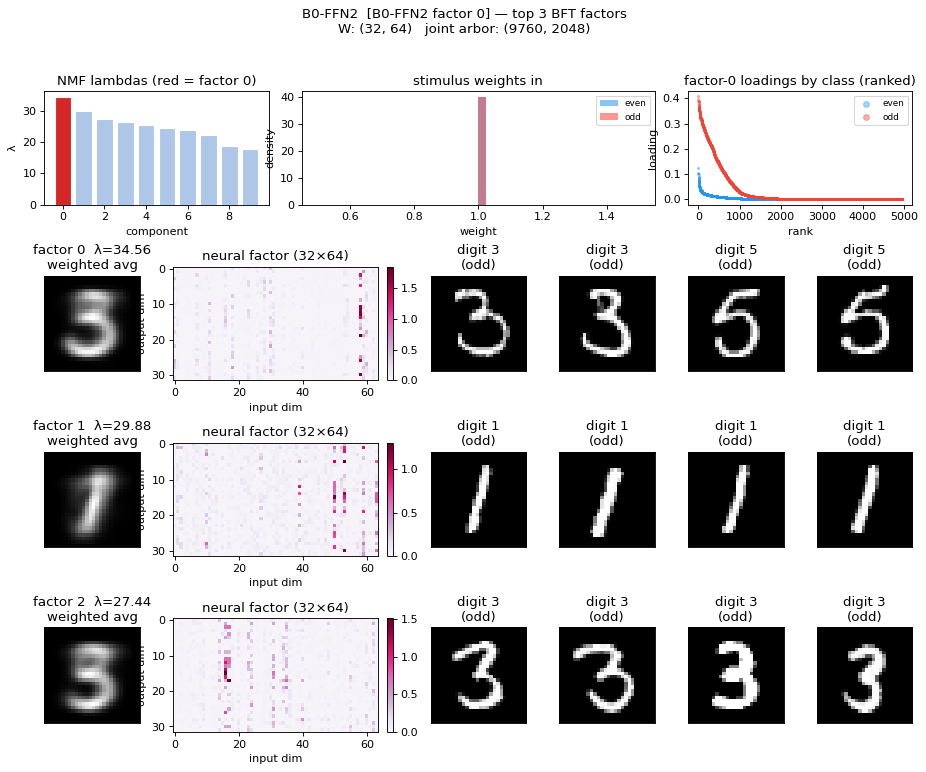

  [B0-FFN2 factor 0] B0-FFN2: k*=10  λ[:3]=[34.556, 29.879, 27.44]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN2_path0.png


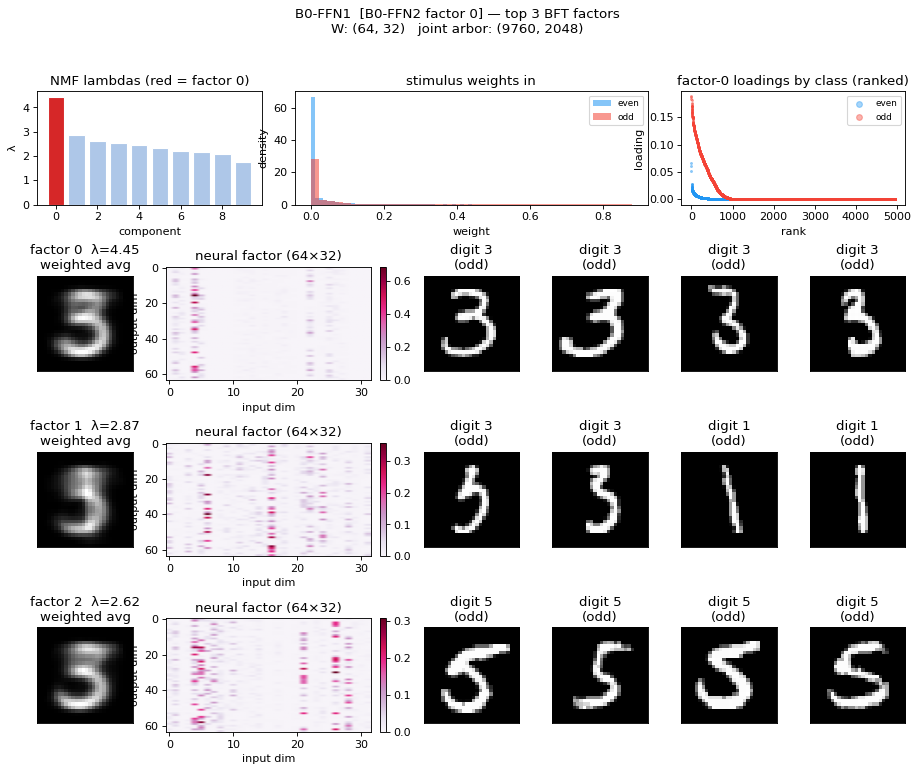

  [B0-FFN2 factor 0] B0-FFN1: k*=10  λ[:3]=[4.449, 2.866, 2.617]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN1_path0.png


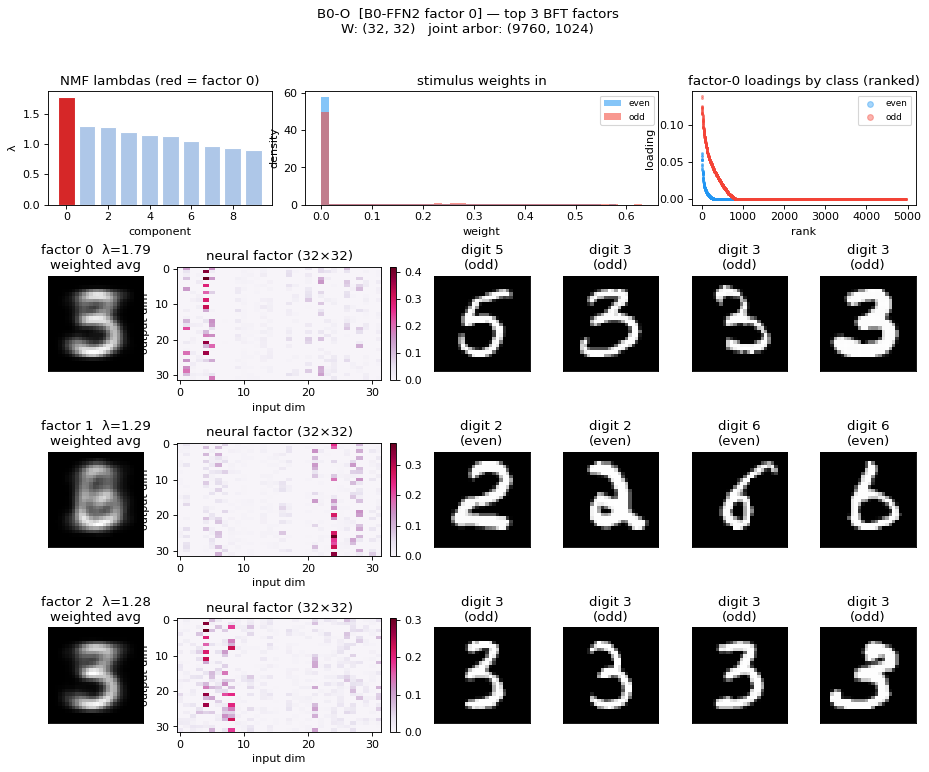

  [B0-FFN2 factor 0] B0-O: k*=10  λ[:3]=[1.789, 1.295, 1.278]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0O_path0.png


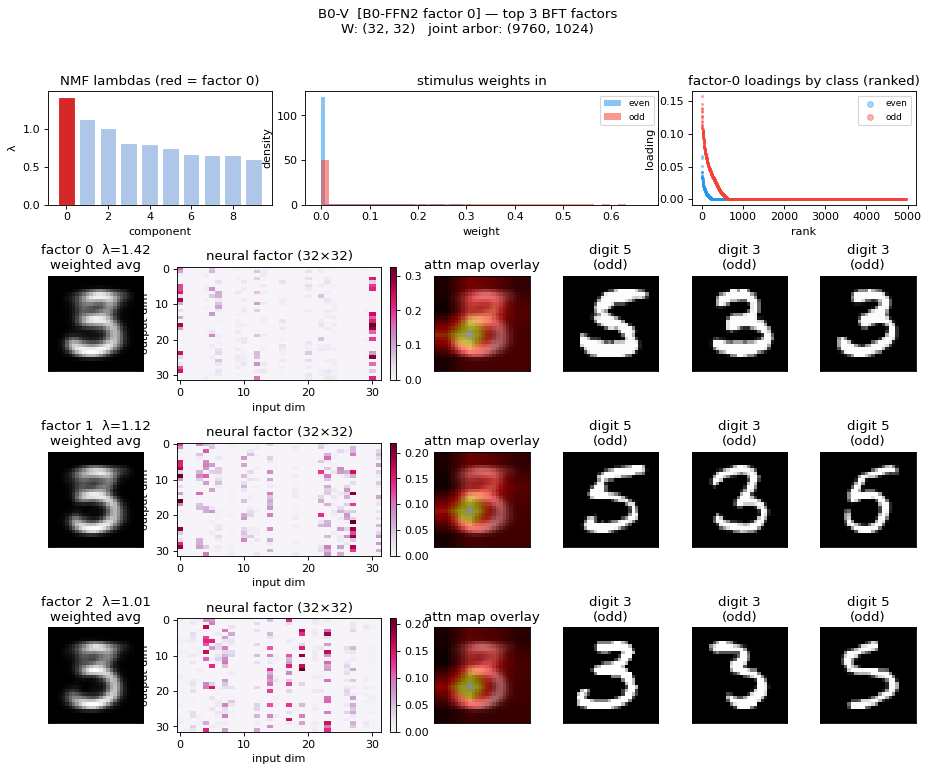

  [B0-FFN2 factor 0] B0-V: k*=10  λ[:3]=[1.425, 1.123, 1.006]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0V_path0.png


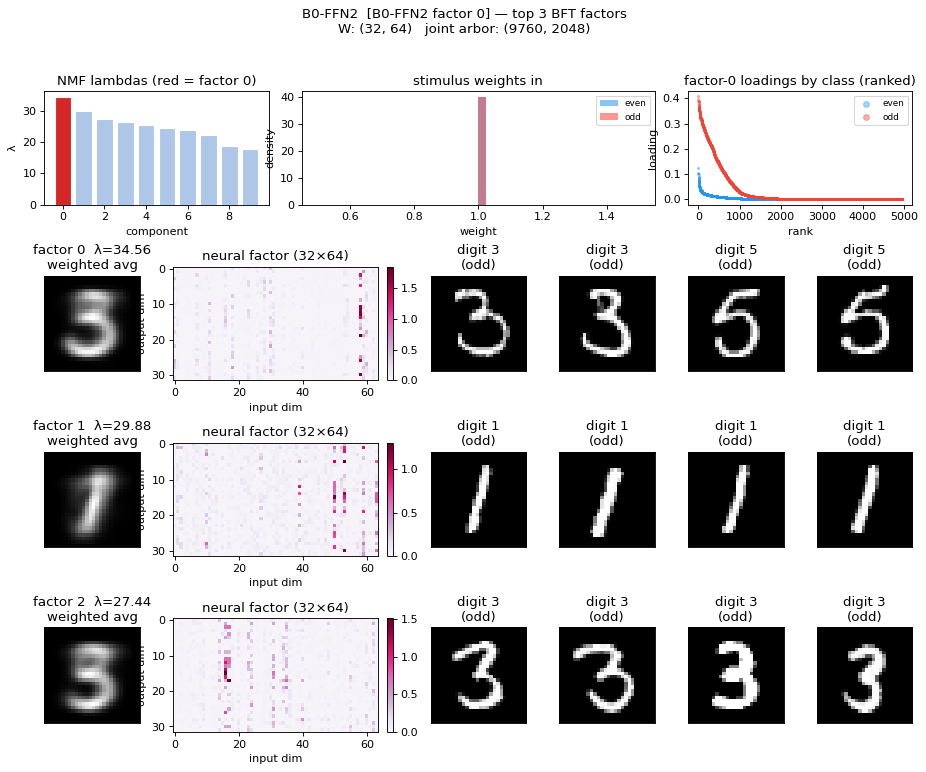

  [B0-FFN2 factor 0] B0-FFN2: k*=10  λ[:3]=[34.556, 29.879, 27.44]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN2_path0.png


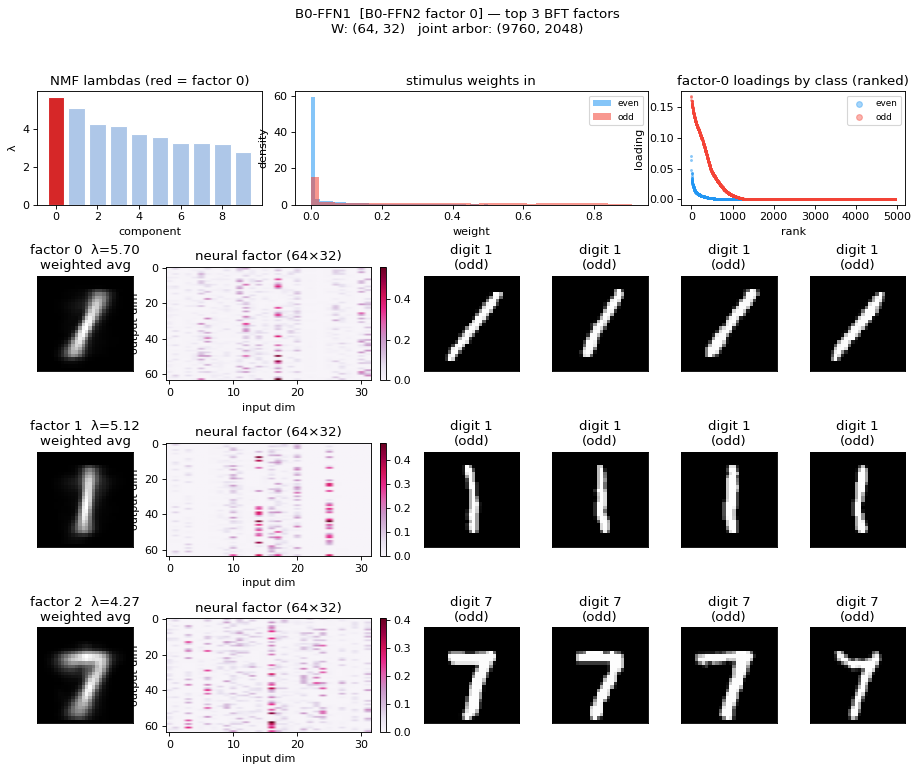

  [B0-FFN2 factor 0] B0-FFN1: k*=10  λ[:3]=[5.7, 5.117, 4.267]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN1_path0.png
  [B0-FFN2 factor 0] B0-O: k*=10  λ[:3]=[2.738, 1.227, 1.181]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0O_path0.png
  [B0-FFN2 factor 0] B0-V: k*=10  λ[:3]=[2.557, 1.863, 1.716]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0V_path0.png
  [B0-FFN2 factor 0] B0-FFN2: k*=10  λ[:3]=[34.556, 29.879, 27.44]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN2_path0.png
  [B0-FFN2 factor 0] B0-FFN1: k*=10  λ[:3]=[3.91, 3.082, 3.02]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_trace/factor_viz_B0FFN1_path0.png
  [B0-FFN2 factor 0] B0-O: k*=10  λ[:3]=[1.728, 1.421, 1.352]  → /Users/johannesbertram/repos/Weight_Interpretability/figs/05_transformer_t

In [ ]:
_inline_shown = 0
_MAX_INLINE   = 6   # show at most 6 figures inline; rest saved only

for path_nodes in all_paths:
    fi_last    = path_nodes[0]['factor_idx']
    path_label = f'B0-FFN2 factor {fi_last}'

    for r in path_nodes:
        lname  = r['layer_name']
        ltype  = r['layer_type']
        img_f  = r['img_factors']       # (N, K)
        neu_f  = r['neural_factors']    # (n_out*n_in, K)
        lams   = r['lambdas']           # (K,)
        W      = r['W']                 # (n_out, n_in)
        n_out, n_in = W.shape
        n_show = min(N_VIZ, len(lams))

        # Extra column for the attention overlay (attn layers only)
        has_attn_overlay = (ltype == 'attn') and ('attn_weights' in r)
        n_img_cols = 3 if has_attn_overlay else 4  # top-N sample images to show

        fig = plt.figure(figsize=(14, 2.6 * (n_show + 1)))
        fig.suptitle(
            f'{lname}  [{path_label}] — top {n_show} BFT factors\n'
            f'W: {W.shape}   joint arbor: {r["joint_arbor"].shape}',
            fontsize=12,
        )
        gs = gridspec.GridSpec(n_show + 1, 7, figure=fig, hspace=0.55, wspace=0.35)

        # ── Row 0: overview ────────────────────────────────────────────────────
        # Lambda bar chart
        ax_lam = fig.add_subplot(gs[0, 0:2])
        bar_colors = ['#d62728'] + ['#aec7e8'] * (len(lams) - 1)
        ax_lam.bar(range(len(lams)), lams, color=bar_colors, edgecolor='white')
        ax_lam.set(title='NMF lambdas (red = factor 0)',
                   xlabel='component', ylabel='λ')

        # Stimulus-weight histogram by class
        ax_sw = fig.add_subplot(gs[0, 2:5])
        sw = r['stimulus_weights_in']
        for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], ['even', 'odd']):
            ax_sw.hist(sw[all_targets == cl], bins=40, alpha=0.55,
                       density=True, color=color, label=name)
        ax_sw.set(title='stimulus weights in', xlabel='weight', ylabel='density')
        ax_sw.legend(fontsize=8)

        # Ranked factor-0 loading scatter by class
        ax_cls = fig.add_subplot(gs[0, 5:7])
        for cl, color, name in zip([0, 1], ['#2196F3', '#F44336'], ['even', 'odd']):
            mask   = all_targets == cl
            coefs0 = img_f[mask, 0]
            ax_cls.scatter(np.arange(mask.sum()), np.sort(coefs0)[::-1],
                           s=3, alpha=0.4, color=color, label=name)
        ax_cls.set(title='factor-0 loadings by class (ranked)',
                   xlabel='rank', ylabel='loading')
        ax_cls.legend(markerscale=3, fontsize=8)

        # ── Factor rows ────────────────────────────────────────────────────────
        for fi in range(n_show):
            coefs_k    = img_f[:, fi]
            per_neuron = neu_f[:, fi].reshape(n_out, n_in)
            w_norm     = coefs_k / (coefs_k.sum() + 1e-12)

            # Weighted average image
            ax_wav = fig.add_subplot(gs[fi + 1, 0])
            w_avg  = (w_norm[:, None, None] * all_images[:, 0]).sum(0)
            ax_wav.imshow(w_avg, cmap='gray')
            ax_wav.set(title=f'factor {fi}  λ={lams[fi]:.2f}\nweighted avg',
                       xticks=[], yticks=[])

            # Neural factor heatmap (n_out × n_in)
            ax_nf  = fig.add_subplot(gs[fi + 1, 1:3])
            vmax   = np.abs(per_neuron).max() or 1.0
            im     = ax_nf.imshow(per_neuron, aspect='auto', cmap='PuRd',
                                  vmin=0, vmax=vmax)
            plt.colorbar(im, ax=ax_nf, fraction=0.046, pad=0.04)
            ax_nf.set(title=f'neural factor ({n_out}×{n_in})',
                      xlabel='input dim', ylabel='output dim')

            # Attention overlay (attention layers only)
            if has_attn_overlay:
                attn_patch = r['attn_weights'][:, 1:]   # (N, 16) drop CLS token
                avg_attn   = (w_norm[:, None] * attn_patch).sum(0)
                attn_grid  = avg_attn.reshape(4, 4)
                attn_up    = F.interpolate(
                    torch.tensor(attn_grid).float().unsqueeze(0).unsqueeze(0),
                    size=(28, 28), mode='bilinear', align_corners=False,
                ).squeeze().numpy()
                ax_attn = fig.add_subplot(gs[fi + 1, 3])
                ax_attn.imshow(w_avg, cmap='gray')
                ax_attn.imshow(attn_up, cmap='hot', alpha=0.55, vmin=0)
                ax_attn.set(title='attn map overlay', xticks=[], yticks=[])
                img_col_start = 4
            else:
                img_col_start = 3

            # Top-N highest-loading samples
            top_idx = np.argsort(coefs_k)[::-1][:n_img_cols]
            for col_i, s_idx in enumerate(top_idx):
                col = img_col_start + col_i
                if col >= 7:
                    break
                ax_img = fig.add_subplot(gs[fi + 1, col])
                ax_img.imshow(all_images[s_idx, 0], cmap='gray')
                ax_img.set(
                    title=f'digit {all_digits[s_idx]}\n({CLASS_NAMES[all_targets[s_idx]]})',
                    xticks=[], yticks=[],
                )

        fname = os.path.join(
            FIG_DIR,
            f'factor_viz_{lname.replace("-","").replace(" ","_")}_path{fi_last}.png',
        )
        fig.savefig(fname, dpi=100, bbox_inches='tight')
        if _inline_shown < _MAX_INLINE:
            plt.show()
            _inline_shown += 1
        else:
            plt.close(fig)
        print(f'  [{path_label}] {lname}: k*={len(lams)}  '
              f'λ[:3]={np.round(lams[:3], 3).tolist()}  → {fname}')